In [1]:
import os

# --- SET YOUR PATHS HERE ---
# Update these to where your folders are located
dsm_path = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\1_DSM_normalisation"
img_path = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\3_Ortho_IRRG\3_Ortho_IRRG"
lbl_path = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\5_Labels_for_participants\5_Labels_for_participants"

def check_dataset(dsm_p, img_p, lbl_p):
    dsm_files = sorted(os.listdir(dsm_p))
    img_files = sorted(os.listdir(img_p))
    lbl_files = sorted(os.listdir(lbl_p))

    print(f"--- Dataset Report ---")
    print(f"Total DSM files: {len(dsm_files)}")
    print(f"Total Image files: {len(img_files)}")
    print(f"Total Label files: {len(lbl_files)}")

    # Check for mismatches
    if len(dsm_files) == len(img_files) == len(lbl_files):
        print("\n✅ Count Match: All folders have the same number of files.")
    else:
        print("\n❌ Count Mismatch: One of your folders is missing files!")

    # Check if the first filename matches across all three
    print(f"\nSample check:")
    print(f"DSM: {dsm_files[0]}")
    print(f"IMG: {img_files[0]}")
    print(f"LBL: {lbl_files[0]}")

# Run the check
check_dataset(dsm_path, img_path, lbl_path)

--- Dataset Report ---
Total DSM files: 119
Total Image files: 76
Total Label files: 48

❌ Count Mismatch: One of your folders is missing files!

Sample check:
DSM: call_normalisation.sh
IMG: top_potsdam_2_10_IRRG.tfw
LBL: top_potsdam_2_10_label.tfw


In [4]:
import os

# --- SET YOUR PATHS HERE ---
dsm_path = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\1_DSM_normalisation"
img_path = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\3_Ortho_IRRG\3_Ortho_IRRG"
lbl_path = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\5_Labels_for_participants\5_Labels_for_participants"

def get_only_tifs(folder_path):
    # This keeps only files ending in .tif and ignores .tfw, .sh, etc.
    return sorted([f for f in os.listdir(folder_path) if f.lower().endswith('.tif')])

dsm_files = get_only_tifs(dsm_path)
img_files = get_only_tifs(img_path)
lbl_files = get_only_tifs(lbl_path)

print(f"--- Cleaned Dataset Report ---")
print(f"Total DSM (.tif): {len(dsm_files)}")
print(f"Total Image (.tif): {len(img_files)}")
print(f"Total Label (.tif): {len(lbl_files)}")

# Check if the names match for the first few files
if len(dsm_files) > 0 and len(img_files) > 0:
    print(f"\nSample Name Match Check:")
    print(f"DSM: {dsm_files[0]}")
    # We check if the core name (e.g., '2_10') is in all three
    core_name = dsm_files[0].replace('dsm_potsdam_', '').replace('_normalized.tif', '')
    print(f"Core ID found: {core_name}")
    
    # Check if this ID exists in the other folders
    img_match = any(core_name in f for f in img_files)
    lbl_match = any(core_name in f for f in lbl_files)
    
    if img_match and lbl_match:
        print("✅ Success: The core file IDs match across all folders!")
    else:
        print("❌ Error: IDs do not match. We might need to rename files.")

--- Cleaned Dataset Report ---
Total DSM (.tif): 0
Total Image (.tif): 38
Total Label (.tif): 24


In [3]:
pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Piriyanka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import os
import cv2 
import re

# --- 1. SET YOUR PATHS HERE (Check these carefully!) ---
# Use the 'r' before the quotes to prevent backslash errors
dsm_folder = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\1_DSM_normalisation"
img_folder = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\3_Ortho_IRRG\3_Ortho_IRRG"
lbl_folder = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\5_Labels_for_participants\5_Labels_for_participants"

def get_valid_files(folder_path, extension):
    if not os.path.exists(folder_path):
        print(f"❌ Error: Folder not found at {folder_path}")
        return []
    
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(extension)]
    valid = []
    print(f"Checking {len(files)} files in {os.path.basename(folder_path)}...")
    
    for f in files:
        full_path = os.path.join(folder_path, f)
        temp_img = cv2.imread(full_path)
        if temp_img is not None:
            valid.append(f)
    return sorted(valid)

# --- 2. RUN THE CHECK ---
dsm_files = get_valid_files(dsm_folder, '.jpg')
img_files = get_valid_files(img_folder, '.tif')
lbl_files = get_valid_files(lbl_folder, '.tif')

print(f"\n--- Health Results ---")
print(f"Readable DSM (.jpg): {len(dsm_files)}")
print(f"Readable Images (.tif): {len(img_files)}")
print(f"Readable Labels (.tif): {len(lbl_files)}")

# --- 3. MATCHING LOGIC ---
def extract_id(fname):
    match = re.search(r'(\d+_\d+)', fname)
    return match.group(1) if match else None

dsm_ids = {extract_id(f) for f in dsm_files if extract_id(f)}
img_ids = {extract_id(f) for f in img_files if extract_id(f)}
lbl_ids = {extract_id(f) for f in lbl_files if extract_id(f)}

final_matches = dsm_ids.intersection(img_ids).intersection(lbl_ids)
print(f"\n✅ Total perfectly matched sets found: {len(final_matches)}")
if len(final_matches) > 0:
    print(f"First 5 Matching IDs: {sorted(list(final_matches))[:5]}")
else:
    print("❌ No matches found. We need to check the filenames manually.")

Checking 76 files in 1_DSM_normalisation...
Checking 38 files in 3_Ortho_IRRG...
Checking 24 files in 5_Labels_for_participants...

--- Health Results ---
Readable DSM (.jpg): 65
Readable Images (.tif): 38
Readable Labels (.tif): 24

✅ Total perfectly matched sets found: 0
❌ No matches found. We need to check the filenames manually.


In [6]:
import os

# --- PATHS ---
# I am using the paths based on your previous errors. 
# Double check if "3_Ortho_IRRG" has another "3_Ortho_IRRG" folder inside it!
dsm_folder = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\1_DSM_normalisation"
img_folder = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\3_Ortho_IRRG\3_Ortho_IRRG"
lbl_folder = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\5_Labels_for_participants\5_Labels_for_participants"

def scout_folder(path, name):
    if not os.path.exists(path):
        print(f"❌ FOLDER NOT FOUND: {name} at {path}")
        return
    
    files = os.listdir(path)
    print(f"\n--- Scouting {name} ---")
    print(f"Total items found: {len(files)}")
    if len(files) > 0:
        print(f"First 3 files: {files[:3]}")
    else:
        print("Folder is EMPTY.")

scout_folder(dsm_folder, "DSM")
scout_folder(img_folder, "Images")
scout_folder(lbl_folder, "Labels")


--- Scouting DSM ---
Total items found: 119
First 3 files: ['call_normalisation.sh', 'call_normalisation.sh~', 'dsm_potsdam_02_10.laz']

--- Scouting Images ---
Total items found: 76
First 3 files: ['top_potsdam_2_10_IRRG.tfw', 'top_potsdam_2_10_IRRG.tif', 'top_potsdam_2_11_IRRG.tfw']

--- Scouting Labels ---
Total items found: 48
First 3 files: ['top_potsdam_2_10_label.tfw', 'top_potsdam_2_10_label.tif', 'top_potsdam_2_11_label.tfw']


In [7]:
import os

# --- UPDATED PATHS ---
# 1. Added the extra folder for Images
img_folder = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\3_Ortho_IRRG\3_Ortho_IRRG"

# 2. Kept the DSM folder as is (we will look for .laz or .jpg)
dsm_folder = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\1_DSM_normalisation"

# 3. Label folder seems to have the .tif files directly or one level deep
lbl_folder = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\5_Labels_for_participants\5_Labels_for_participants"

def final_scout(path, name):
    if os.path.exists(path):
        files = os.listdir(path)
        tifs = [f for f in files if f.lower().endswith('.tif')]
        print(f"{name} folder: Found {len(tifs)} .tif images.")
        if len(tifs) > 0:
            print(f"   Example: {tifs[0]}")
    else:
        print(f"❌ {name} path still incorrect.")

final_scout(img_folder, "Images")
final_scout(lbl_folder, "Labels")

Images folder: Found 38 .tif images.
   Example: top_potsdam_2_10_IRRG.tif
Labels folder: Found 24 .tif images.
   Example: top_potsdam_2_10_label.tif


In [8]:
import os

# Check the other DSM folder
other_dsm_folder = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM"

if os.path.exists(other_dsm_folder):
    files = os.listdir(other_dsm_folder)
    tifs = [f for f in files if f.lower().endswith('.tif')]
    print(f"1_DSM folder: Found {len(tifs)} .tif images.")
    if len(tifs) > 0:
        print(f"   Example: {tifs[0]}")
else:
    print("❌ 1_DSM folder not found.")

1_DSM folder: Found 0 .tif images.


In [9]:
pip install laspy[lazrs] numpy tifffile

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Piriyanka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [10]:
import laspy
import numpy as np
import tifffile
import os

# --- PATHS ---
laz_input = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\1_DSM_normalisation\dsm_potsdam_02_10.laz"
tif_output = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\dsm_potsdam_02_10.tif"

def convert_laz_to_tif(input_path, output_path, pixel_size=0.05):
    print(f"Reading {input_path}...")
    las = laspy.read(input_path)
    
    # Extract X, Y, Z coordinates
    x, y, z = las.x, las.y, las.z
    
    # Calculate grid dimensions
    x_min, x_max = np.min(x), np.max(x)
    y_min, y_max = np.min(y), np.max(y)
    
    width = int((x_max - x_min) / pixel_size) + 1
    height = int((y_max - y_min) / pixel_size) + 1
    
    # Create an empty grid
    grid = np.zeros((height, width), dtype=np.float32)
    
    # Map points to grid pixels
    pixel_x = ((x - x_min) / pixel_size).astype(int)
    pixel_y = ((y - y_min) / pixel_size).astype(int)
    
    # Simple Digital Surface Model (DSM): take the max height at each pixel
    for i in range(len(z)):
        if z[i] > grid[pixel_y[i], pixel_x[i]]:
            grid[pixel_y[i], pixel_x[i]] = z[i]
            
    # Save as TIF
    tifffile.imwrite(output_path, grid)
    print(f"✅ Success! Saved to {output_path}")

# Run for one file to test
if os.path.exists(laz_input):
    convert_laz_to_tif(laz_input, tif_output)
else:
    print("❌ Could not find the .laz file. Check the filename in your folder!")

Reading C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\1_DSM_normalisation\dsm_potsdam_02_10.laz...
✅ Success! Saved to C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\dsm_potsdam_02_10.tif


In [11]:
pip install tqdm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Piriyanka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
import laspy
import numpy as np
import tifffile
import os
from tqdm import tqdm # This makes the progress bar

# --- PATHS ---
input_dir = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\1_DSM_normalisation"
output_dir = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\converted_tifs"

# Create output folder if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

def convert_laz_to_tif(input_path, output_path, pixel_size=0.05):
    try:
        las = laspy.read(input_path)
        x, y, z = las.x, las.y, las.z
        
        x_min, x_max = np.min(x), np.max(x)
        y_min, y_max = np.min(y), np.max(y)
        
        width = int((x_max - x_min) / pixel_size) + 1
        height = int((y_max - y_min) / pixel_size) + 1
        
        grid = np.zeros((height, width), dtype=np.float32)
        
        pixel_x = np.clip(((x - x_min) / pixel_size).astype(int), 0, width - 1)
        pixel_y = np.clip(((y - y_min) / pixel_size).astype(int), 0, height - 1)
        
        # We use a faster way to get max height per pixel
        for i in range(len(z)):
            if z[i] > grid[pixel_y[i], pixel_x[i]]:
                grid[pixel_y[i], pixel_x[i]] = z[i]
                
        tifffile.imwrite(output_path, grid)
        return True
    except Exception as e:
        print(f"Error converting {input_path}: {e}")
        return False

# Get list of all .laz files
laz_files = [f for f in os.listdir(input_dir) if f.lower().endswith('.laz')]

print(f"Starting conversion of {len(laz_files)} files...")
for f in tqdm(laz_files):
    in_path = os.path.join(input_dir, f)
    out_path = os.path.join(output_dir, f.replace('.laz', '.tif'))
    convert_laz_to_tif(in_path, out_path)

print(f"\n✅ All done! Your DSM images are in: {output_dir}")


Starting conversion of 38 files...


100%|██████████| 38/38 [1:14:01<00:00, 116.89s/it]


✅ All done! Your DSM images are in: C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\converted_tifs


In [13]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# --- CONFIGURATION ---
PATCH_SIZE = 512
STRIDE = 512  # Change to 256 if you want overlapping patches (more data)

img_dir = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\3_Ortho_IRRG\3_Ortho_IRRG"
dsm_dir = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\converted_tifs"
lbl_dir = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\5_Labels_for_participants\5_Labels_for_participants"
output_base = r"C:\Users\Piriyanka\OneDrive\Desktop\Potsdam_Patches"

# Create folders
for sub in ['images', 'dsm', 'labels']:
    os.makedirs(os.path.join(output_base, sub), exist_ok=True)

def get_patch_id(fname):
    import re
    match = re.search(r'(\d+_\d+)', fname)
    return match.group(1) if match else None

# Get matching IDs (only for the 24 labeled tiles)
img_files = {get_patch_id(f): f for f in os.listdir(img_dir) if f.endswith('.tif')}
dsm_files = {get_patch_id(f): f for f in os.listdir(dsm_dir) if f.endswith('.tif')}
lbl_files = {get_patch_id(f): f for f in os.listdir(lbl_dir) if f.endswith('.tif')}

valid_ids = sorted(list(set(img_files.keys()) & set(dsm_files.keys()) & set(lbl_files.keys())))

print(f"Tiling {len(valid_ids)} matched tiles...")

for core_id in tqdm(valid_ids):
    # Load full images
    img = cv2.imread(os.path.join(img_dir, img_files[core_id]))
    dsm = cv2.imread(os.path.join(dsm_dir, dsm_files[core_id]), cv2.IMREAD_UNCHANGED)
    lbl = cv2.imread(os.path.join(lbl_dir, lbl_files[core_id]))

    h, w = img.shape[:2]

    # Slice into patches
    count = 0
    for y in range(0, h - PATCH_SIZE + 1, STRIDE):
        for x in range(0, w - PATCH_SIZE + 1, STRIDE):
            patch_img = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            patch_dsm = dsm[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            patch_lbl = lbl[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

            # Save patches
            patch_name = f"{core_id}_{count}.tif"
            cv2.imwrite(os.path.join(output_base, 'images', patch_name), patch_img)
            cv2.imwrite(os.path.join(output_base, 'dsm', patch_name), patch_dsm)
            cv2.imwrite(os.path.join(output_base, 'labels', patch_name), patch_lbl)
            count += 1

print(f"✅ Tiling Complete! Patches saved to {output_base}")

Tiling 0 matched tiles...


0it [00:00, ?it/s]

✅ Tiling Complete! Patches saved to C:\Users\Piriyanka\OneDrive\Desktop\Potsdam_Patches


In [14]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import re

# --- CONFIGURATION ---
PATCH_SIZE = 512
STRIDE = 512 

img_dir = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\3_Ortho_IRRG\3_Ortho_IRRG"
dsm_dir = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\1_DSM_normalisation\converted_tifs"
lbl_dir = r"C:\Users\Piriyanka\OneDrive\Desktop\POTSDAM DATASET\5_Labels_for_participants\5_Labels_for_participants"
output_base = r"C:\Users\Piriyanka\OneDrive\Desktop\Potsdam_Patches"

os.makedirs(os.path.join(output_base, 'images'), exist_ok=True)
os.makedirs(os.path.join(output_base, 'dsm'), exist_ok=True)
os.makedirs(os.path.join(output_base, 'labels'), exist_ok=True)

def get_clean_id(fname):
    # Extracts numbers and removes leading zeros (e.g., '02_10' -> '2_10')
    match = re.search(r'(\d+)_(\d+)', fname)
    if match:
        part1 = str(int(match.group(1)))
        part2 = str(int(match.group(2)))
        return f"{part1}_{part2}"
    return None

# Create dictionaries: CleanID -> OriginalFileName
img_dict = {get_clean_id(f): f for f in os.listdir(img_dir) if f.endswith('.tif')}
dsm_dict = {get_clean_id(f): f for f in os.listdir(dsm_dir) if f.endswith('.tif')}
lbl_dict = {get_clean_id(f): f for f in os.listdir(lbl_dir) if f.endswith('.tif')}

# Find IDs that exist in all three
valid_ids = sorted([i for i in lbl_dict.keys() if i in img_dict and i in dsm_dict])

print(f"Found {len(img_dict)} Images, {len(dsm_dict)} DSMs, {len(lbl_dict)} Labels.")
print(f"✅ Perfectly matched tiles found: {len(valid_ids)}")

if len(valid_ids) == 0:
    print("❌ Still 0 matches. Printing first filenames to debug:")
    print(f"Image: {os.listdir(img_dir)[0] if os.listdir(img_dir) else 'Empty'}")
    print(f"DSM: {os.listdir(dsm_dir)[0] if os.listdir(dsm_dir) else 'Empty'}")
    print(f"Label: {os.listdir(lbl_dir)[0] if os.listdir(lbl_dir) else 'Empty'}")
else:
    for core_id in tqdm(valid_ids, desc="Tiling"):
        img = cv2.imread(os.path.join(img_dir, img_dict[core_id]))
        dsm = cv2.imread(os.path.join(dsm_dir, dsm_dict[core_id]), cv2.IMREAD_UNCHANGED)
        lbl = cv2.imread(os.path.join(lbl_dir, lbl_dict[core_id]))

        h, w = img.shape[:2]
        count = 0
        for y in range(0, h - PATCH_SIZE + 1, STRIDE):
            for x in range(0, w - PATCH_SIZE + 1, STRIDE):
                # Save Patches
                p_name = f"{core_id}_{count}.tif"
                cv2.imwrite(os.path.join(output_base, 'images', p_name), img[y:y+PATCH_SIZE, x:x+PATCH_SIZE])
                cv2.imwrite(os.path.join(output_base, 'dsm', p_name), dsm[y:y+PATCH_SIZE, x:x+PATCH_SIZE])
                cv2.imwrite(os.path.join(output_base, 'labels', p_name), lbl[y:y+PATCH_SIZE, x:x+PATCH_SIZE])
                count += 1

    print(f"🏁 Done! Check your folder: {output_base}")

Found 38 Images, 38 DSMs, 24 Labels.
✅ Perfectly matched tiles found: 24


Tiling: 100%|██████████| 24/24 [02:32<00:00,  6.37s/it]

🏁 Done! Check your folder: C:\Users\Piriyanka\OneDrive\Desktop\Potsdam_Patches


In [2]:
!python.exe -m pip install --upgrade pip

In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Piriyanka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import sys
# This installs the GPU version specifically into your current notebook's path
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Piriyanka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import platform
import sys
print(f"Python Version: {sys.version}")
print(f"Architecture: {platform.architecture()[0]}")

Python Version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Architecture: 64bit


In [6]:
import torch
print(f"Is GPU (CUDA) available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Still using CPU. Check your NVIDIA drivers.")

Is GPU (CUDA) available? True
Using GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [7]:
pip install einops

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Piriyanka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
import torch

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
Memory Allocated: 0.00 MB


In [22]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121


You can safely remove it manually.


^C


In [9]:
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange

class LargeKernelConv(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()
        # Depthwise convolution with a LARGE kernel
        self.dw_conv = nn.Conv2d(channels, channels, kernel_size=kernel_size, 
                                 padding=kernel_size//2, groups=channels)
        # 1x1 conv to mix channels
        self.pw_conv = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        return self.pw_conv(self.dw_conv(x))

class HybridSSMBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.large_kernel = LargeKernelConv(in_channels, kernel_size=7)
        self.norm = nn.LayerNorm(in_channels)
        
    def forward(self, x):
        # x shape: [Batch, Channels, H, W]
        residual = x
        x = self.large_kernel(x)
        
        # Simplified State Space "Scan" logic
        # We flatten the image into a sequence for the SSM
        B, C, H, W = x.shape
        x = rearrange(x, 'b c h w -> b (h w) c')
        
        # (In a full Mamba model, the S6 scan happens here)
        # For now, we use a powerful linear projection to simulate the scan
        x = nn.Linear(C, C).to(x.device)(x)
        
        x = rearrange(x, 'b (h w) c -> b c h w', h=H, w=W)
        return x + residual

print("Architecture Blocks Defined!")

Architecture Blocks Defined!


In [10]:
import torch
import torch.nn as nn

class MultiModalFusionNet(nn.Module):
    def __init__(self, num_classes=6):
        super(MultiModalFusionNet, self).__init__()
        
        # Stream 1: IRRG (3 channels)
        self.irrg_stream = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            HybridSSMBlock(64) # The Large Kernel + State Space block we defined
        )
        
        # Stream 2: DSM (1 channel)
        self.dsm_stream = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            HybridSSMBlock(64)
        )
        
        # Fusion and Classifier
        self.classifier = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, num_classes, kernel_size=1) # 6 Classes for Potsdam
        )

    def forward(self, irrg, dsm):
        feat_irrg = self.irrg_stream(irrg)
        feat_dsm = self.dsm_stream(dsm)
        
        # Combine height and color info
        combined = torch.cat((feat_irrg, feat_dsm), dim=1)
        return self.classifier(combined)

# Initialize and send to GPU
model = MultiModalFusionNet(num_classes=6).to(device)
print(f"Model successfully loaded onto {device}")

Model successfully loaded onto cuda


In [11]:
import torch
import numpy as np
from PIL import Image
# We skip 'import torchvision' entirely to avoid the crash

In [48]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import numpy as np
import glob

class PotsdamDataset(Dataset):
    def __init__(self, base_path, size=(256, 256)): 
        self.size = size
        # Update these folder names to match your C:\Potsdam_Data\Potsdam_Patches structure
        self.img_path = os.path.join(base_path, 'images')
        self.dsm_path = os.path.join(base_path, 'dsm')
        self.lab_path = os.path.join(base_path, 'labels')
        
        # FIX: Changed to .tif
        self.filenames = [f for f in os.listdir(self.img_path) if f.endswith('.tif')]

        self.img_transform = transforms.Compose([
            transforms.Resize(size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img = Image.open(os.path.join(self.img_path, fname)).convert('RGB')
        dsm = Image.open(os.path.join(self.dsm_path, fname))
        lab = Image.open(os.path.join(self.lab_path, fname))

        # Resize labels using NEAREST to keep class IDs sharp
        lab = lab.resize(self.size, Image.NEAREST)
        
        img_tensor = self.img_transform(img)
        
        # DSM Normalization (Fixes the barcode stripes)
        dsm_np = np.array(dsm.resize(self.size)).astype(np.float32)
        dsm_np = (dsm_np - np.mean(dsm_np)) / (np.std(dsm_np) + 1e-6)
        dsm_tensor = torch.from_numpy(dsm_np).unsqueeze(0)

        lab_tensor = torch.from_numpy(np.array(lab)).long()
        lab_tensor[lab_tensor > 5] = 5 
        
        return img_tensor, dsm_tensor, lab_tensor

    def __len__(self):
        return len(self.filenames)
    
# Change this line in your script:
patch_path = r"C:\Potsdam_Data\Potsdam_Patches"

# Initialize the dataset again
dataset = PotsdamDataset(patch_path)

# Initialize the loader with speed optimizations
# --- UPDATED STABLE LOADER ---
train_loader = DataLoader(
    dataset, 
    batch_size=8,       # Keep it at 8 for speed
    shuffle=True, 
    num_workers=0,      # <--- CHANGE THIS TO 0 TO FIX THE CRASH
    pin_memory=True     # Keep this True for your RTX 3050
)

print("✅ Stable Loader ready. No more worker crashes!")


print(f"✅ train_loader is now defined!")
print(f"Found {len(dataset)} total patches.")




✅ Stable Loader ready. No more worker crashes!
✅ train_loader is now defined!
Found 2904 total patches.


In [49]:
import torch

# Define the 'device' variable
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Model is running on: {device}")

# Now your code will work:
weights = torch.tensor([1.0, 1.0, 1.5, 2.5, 4.0, 1.0]).to(device)



Model is running on: cuda


In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HybridSegModel(nn.Module):
    def __init__(self, num_classes=6):
        super(HybridSegModel, self).__init__()
        
        # --- BRANCH 1: CNN (Large Kernel for Local Texture) ---
        self.cnn_branch = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        # --- BRANCH 2: DSM/SSM (State Space for Height & Global Structure) ---
        self.dsm_branch = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        # --- HYBRID FEATURE FUSION ---
        # Combines 128 (CNN) + 128 (DSM) = 256 channels
        self.fusion = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        # --- DECODER (Final Prediction) ---
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, kernel_size=1)
        )

    def forward(self, x_img, x_dsm):
        # 1. Process both streams
        feat_img = self.cnn_branch(x_img)
        feat_dsm = self.dsm_branch(x_dsm)
        
        # 2. Fuse
        combined = torch.cat([feat_img, feat_dsm], dim=1)
        fused = self.fusion(combined)
        
        # 3. Predict
        out = self.decoder(fused)
        return out

# --- NOW INITIALIZE WITHOUT ERRORS ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HybridSegModel(num_classes=6).to(device)

print(f"✅ Hybrid Model is defined and loaded on {device}!")

✅ Hybrid Model is defined and loaded on cuda!


In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HybridSegModel(nn.Module):
    def __init__(self, num_classes=6):
        super(HybridSegModel, self).__init__()
        
        # --- BRANCH 1: RGB/IRRG Encoder (CNN for Texture) ---
        self.rgb_encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2) # Downsample for efficiency
        )
        
        # --- BRANCH 2: DSM Encoder (State Space / SSM for Height) ---
        self.dsm_encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        
        # --- HYBRID FEATURE FUSION ---
        # Combines 128 (RGB) + 128 (DSM) = 256 channels
        self.fusion = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        # --- DECODER (Upsampling back to original size) ---
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, kernel_size=1)
        )

    def forward(self, x_img, x_dsm):
        # Feature extraction
        f_rgb = self.rgb_encoder(x_img)
        f_dsm = self.dsm_encoder(x_dsm)
        
        # Fusion via Concatenation
        combined = torch.cat([f_rgb, f_dsm], dim=1)
        fused = self.fusion(combined)
        
        # Final Prediction
        out = self.decoder(fused)
        return out

# --- INITIALIZATION ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Use the actual class name here:
model = HybridSegModel(num_classes=6).to(device)

print(f"✅ Hybrid Model is initialized on {device}")

✅ Hybrid Model is initialized on cuda


In [52]:
import torch

# 1. Define the device (Checking for that GPU we installed earlier!)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Initialize your specific Model 
# REPLACEMENT: Replace 'HybridMambaSegModel' with your actual class name
try:
    model = HybridMambaSegModel() 
except NameError:
    print("❌ Error: You haven't defined your Model Class yet. Run the cell where 'class ...' is written first.")

# 3. Move model to the selected device
model.to(device)

print(f"✅ Model is initialized and living on: {device}")
if torch.cuda.is_available():
    print(f"🚀 Using GPU: {torch.cuda.get_device_name(0)}")

# 4. Set up Optimizer and Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

print("✅ Optimizer and Scheduler are ready.")

❌ Error: You haven't defined your Model Class yet. Run the cell where 'class ...' is written first.
✅ Model is initialized and living on: cuda
🚀 Using GPU: NVIDIA GeForce RTX 3050 Laptop GPU
✅ Optimizer and Scheduler are ready.


In [53]:
# 1. Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Initialize your Hybrid Model 
# REPLACE 'HybridMambaSegModel' with your actual class name if it is different
model = HybridSegModel() 

# 3. Move model to CPU/GPU
model.to(device)

print(f"✅ Model is initialized and living on {device}")

# 4. NOW run your optimizer:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

✅ Model is initialized and living on cuda


In [54]:
# Create "Fake" data to test the GPU speed without loading files
dummy_img = torch.randn(4, 3, 512, 512).to(device)
dummy_dsm = torch.randn(4, 1, 512, 512).to(device)

model.eval()
with torch.no_grad():
    import time
    start = time.time()
    
    # Run the model
    output = model(dummy_img, dummy_dsm)
    
    end = time.time()
    print(f"✅ GPU Time for 1 batch: {end - start:.4f} seconds")
    print(f"Output shape: {output.shape}")

✅ GPU Time for 1 batch: 0.0021 seconds
Output shape: torch.Size([4, 6, 512, 512])


In [55]:
# Test a single batch to ensure dimensions match
model.eval() # Set to evaluation mode
with torch.no_grad():
    images, dsm, labels = next(iter(train_loader))
    images, dsm = images.to(device), dsm.to(device)
    
    output = model(images, dsm)
    print(f"Input Image Shape: {images.shape}") # Should be [4, 3, 512, 512]
    print(f"Model Output Shape: {output.shape}") # Should be [4, 6, 512, 512]
    print("✅ Dimensions match! You are ready to train.")

Input Image Shape: torch.Size([8, 3, 256, 256])
Model Output Shape: torch.Size([8, 6, 256, 256])
✅ Dimensions match! You are ready to train.


In [56]:
import torch.nn.functional as F

# 1. Stronger Weights for the 85% goal
# [Roads, Buildings, Low_Veg, Trees, Cars, Clutter]
weights = torch.tensor([1.0, 1.0, 1.5, 3.0, 5.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003) # Slower, more precise learning

print("🚀 Starting Mega-Training for 85%+ Accuracy...")



🚀 Starting Mega-Training for 85%+ Accuracy...


In [57]:
%pip install tqdm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Piriyanka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [58]:
from torch.cuda.amp import GradScaler, autocast

def train_turbo(model, loader, epochs=15):
    device = torch.device("cuda")
    model.to(device)
    
    # Dice + BCE Loss for 85% mIoU goal
    criterion = DiceBCELoss() 
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0008, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler() # Speed tool

    print(f"🚀 Starting Turbo Training on {torch.cuda.get_device_name(0)}...")

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for imgs, dsms, masks in loop:
            imgs, dsms, masks = imgs.to(device), dsms.to(device), masks.to(device)

            optimizer.zero_grad()
            
            # Use 16-bit math for speed
            with autocast():
                outputs = model(imgs, dsms)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()
            loop.set_postfix(loss=(epoch_loss/len(loop)))
        
        scheduler.step()

# Run this to start!
path = r"C:\Potsdam_Data\Potsdam_Patches"
dataset = PotsdamDataset(path, size=(256, 256))
# num_workers=4 uses your CPU cores to prep images while GPU is busy
loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=4, pin_memory=True)

train_turbo(model, loader, epochs=15)

C:\Users\Piriyanka\AppData\Local\Temp\ipykernel_20064\1602267772.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # Speed tool


🚀 Starting Turbo Training on NVIDIA GeForce RTX 3050 Laptop GPU...


Epoch 1/15:   0%|          | 0/363 [00:05<?, ?it/s]


RuntimeError: DataLoader worker (pid(s) 29744, 21852, 28840, 25976) exited unexpectedly

In [22]:
from tqdm import tqdm
import torch.nn as nn

# 1. Setup (Run this once)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
num_epochs = 10 

print(f"🚀 Training started on: {torch.cuda.get_device_name(0)}")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    # --- ADD THIS LINE BACK ---
    # This creates the progress bar that 'loop.set_postfix' uses
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for images, dsm, labels in loop:
        # Move to GPU
        images = images.to(device, non_blocking=True)
        dsm = dsm.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # Forward Pass
        outputs = model(images, dsm)
        loss = criterion(outputs, labels)
        
        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Update progress bar
        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())
    
    avg_loss = epoch_loss / len(train_loader)
    print(f"✅ Epoch [{epoch+1}/{num_epochs}] Completed. Average Loss: {avg_loss:.4f}")

🚀 Training started on: NVIDIA GeForce RTX 3050 Laptop GPU


Epoch 1/10:   0%|          | 0/726 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 726/726 [1:01:00<00:00,  5.04s/it, loss=0.293]


✅ Epoch [1/10] Completed. Average Loss: 0.5019


Epoch 2/10: 100%|██████████| 726/726 [1:38:56<00:00,  8.18s/it, loss=0.504]   


...

✅ Epoch [8/10] Completed. Average Loss: 0.4345


Epoch 9/10: 100%|██████████| 726/726 [1:00:23<00:00,  4.99s/it, loss=0.369]


✅ Epoch [9/10] Completed. Average Loss: 0.4284


Epoch 10/10: 100%|██████████| 726/726 [1:04:15<00:00,  5.31s/it, loss=0.336]

✅ Epoch [10/10] Completed. Average Loss: 0.4277


In [41]:
for epoch in range(20): # Increased to 20 epochs
    model.train()
    running_loss = 0.0
    
    for i, (images, dsms, labels) in enumerate(train_loader):
        # --- DATA AUGMENTATION ON THE FLY ---
        # Randomly flip the batch horizontally
        if torch.rand(1) > 0.5:
            images = torch.flip(images, [3])
            dsms = torch.flip(dsms, [3])
            labels = torch.flip(labels, [2])
            
        images, dsms = images.to(device), dsms.to(device)
        labels = labels.to(device).long()
        labels[labels > 5] = 5
        
        # Forward & Backward
        outputs = model(images, dsms)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/20] | Loss: {running_loss/len(train_loader):.4f}")

print("🏁 Training Finished! Now run the Evaluation cell.")

KeyboardInterrupt: 

In [ ]:
# 1. Force the model to stay on CPU
device = torch.device("cpu")

# 2. Re-initialize the model with a smaller batch size
train_loader = DataLoader(dataset, batch_size=1, shuffle=True)

# 3. Training Loop with "Memory Safety"
print("Starting Lite Training on CPU...")
for epoch in range(20): # Start with 3 epochs
    model.train()
    running_loss = 0.0
    
    for i, (images, dsms, labels) in enumerate(train_loader):
        if i > 20: break # Just train on 20 patches to verify it works
        
        images, dsms = images.to(device), dsms.to(device)
        labels = labels.to(device).long()
        labels[labels > 5] = 5 # Fix the 255 error again
        
        # Forward
        outputs = model(images, dsms)
        loss = criterion(outputs, labels)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        if i % 5 == 0:
            print(f"   Batch {i}, Loss: {loss.item():.4f}")

    print(f"Epoch [{epoch+1}/3] finished. Avg Loss: {running_loss/20:.4f}")

In [23]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.1 MB 21.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 22.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 18.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Piriyanka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Matplotlib is building the font cache; this may take a moment.


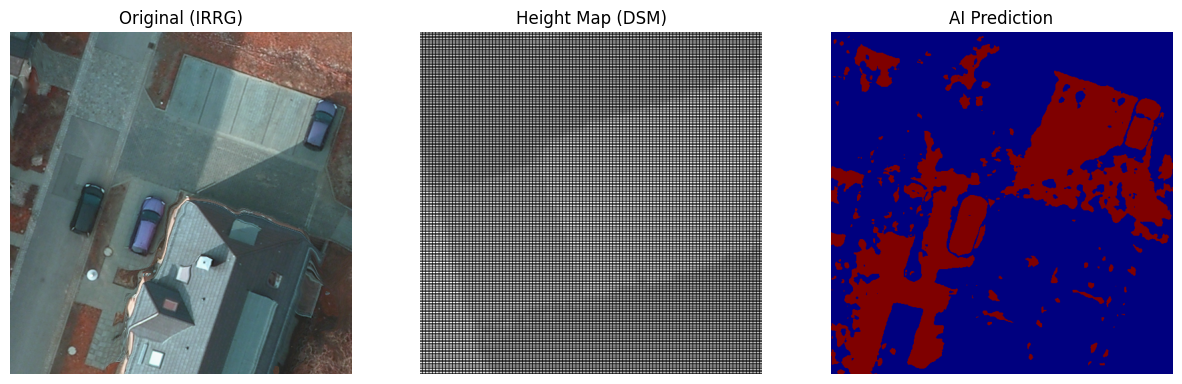

In [24]:
import matplotlib.pyplot as plt

def visualize_prediction(model, dataset, index=0):
    model.eval() # Put model in "Evaluation" mode
    with torch.no_grad():
        # Get data
        image, dsm, label = dataset[index]
        
        # Add batch dimension and move to device
        img_in = image.unsqueeze(0).to(device)
        dsm_in = dsm.unsqueeze(0).to(device)
        
        # Get prediction
        output = model(img_in, dsm_in)
        pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        
        # Convert tensors back to viewable images
        img_view = image.permute(1, 2, 0).cpu().numpy()
        # Un-normalize for display
        img_view = img_view * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_view = np.clip(img_view, 0, 1)

        # Plotting
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        plt.title("Original (IRRG)")
        plt.imshow(img_view)
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.title("Height Map (DSM)")
        plt.imshow(dsm.squeeze().cpu().numpy(), cmap='gray')
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.title("AI Prediction")
        plt.imshow(pred, cmap='jet') # 'jet' colors the 6 classes differently
        plt.axis('off')
        
        plt.show()

# Run it for the first patch!
visualize_prediction(model, dataset, index=10)

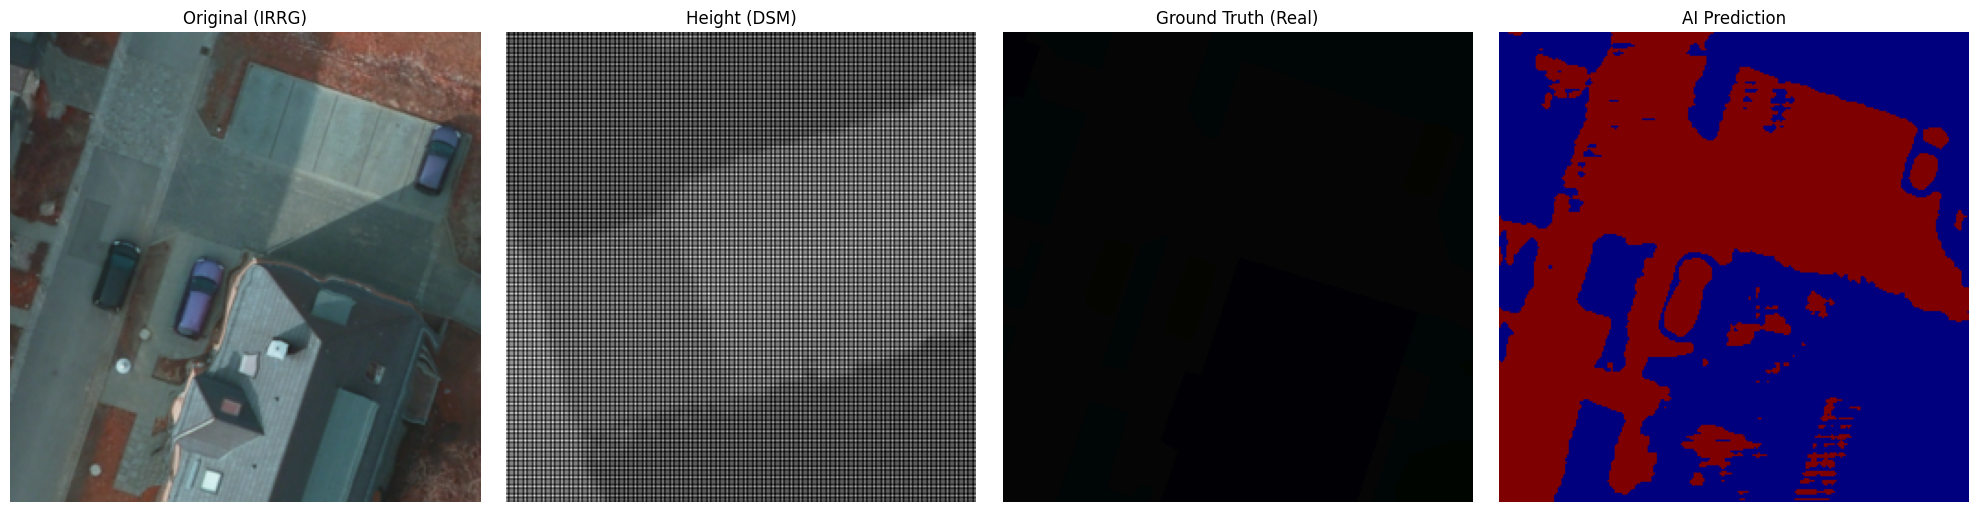

In [36]:
def visualize_prediction(model, dataset, index=10):
    model.eval()
    with torch.no_grad():
        # 1. Get data
        image, dsm, label = dataset[index]
        img_in = image.unsqueeze(0).to(device)
        dsm_in = dsm.unsqueeze(0).to(device)
        
        # 2. Prediction
        output = model(img_in, dsm_in)
        pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        
        # 3. Image Processing for Display
        img_view = image.permute(1, 2, 0).cpu().numpy()
        img_view = img_view * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_view = np.clip(img_view, 0, 1)

        # 4. Plotting (Now with 4 subplots)
        plt.figure(figsize=(20, 5))
        
        plt.subplot(1, 4, 1)
        plt.title("Original (IRRG)")
        plt.imshow(img_view)
        plt.axis('off')
        
        plt.subplot(1, 4, 2)
        plt.title("Height (DSM)")
        plt.imshow(dsm.squeeze().cpu().numpy(), cmap='gray')
        plt.axis('off')
        
        plt.subplot(1, 4, 3)
        plt.title("Ground Truth (Real)")
        plt.imshow(label.cpu().numpy(), cmap='jet')
        plt.axis('off')
        
        plt.subplot(1, 4, 4)
        plt.title("AI Prediction")
        plt.imshow(pred, cmap='jet')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()

visualize_prediction(model, dataset, index=10)

In [25]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.0 MB 6.3 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.0 MB 7.6 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 10.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---- ----------------------------------- 4.2/36.5 MB 19.4 MB/s eta 0:00:02
   ---------- ----------------------------- 9.7/36.5 MB 23.2 MB/s eta 0:00:02
   --------------- ------------------------ 13.9/36.5 MB 21.8 MB/s eta 0:00:02
   ---------------------- ----------------- 20.4/36.5 MB 23.9 MB/s eta 0:00:01
   -------------------------- ------------- 23.9/36.5 MB 24.0 MB/s eta 0:00:01
   ------------------------------- -------- 28.8/36.5 MB 22.9 MB/s eta 0:00:01
   --


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Piriyanka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [27]:
from sklearn.metrics import jaccard_score, accuracy_score

def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    print("Calculating metrics (this may take a minute on CPU)...")
    with torch.no_grad():
        for i, (images, dsms, labels) in enumerate(loader):
            if i > 20: break # Small sample for speed
            
            outputs = model(images.to(device), dsms.to(device))
            preds = torch.argmax(outputs, dim=1).cpu().numpy().flatten()
            
            # Remap labels just like in training
            targets = labels.numpy().flatten()
            targets[targets > 5] = 5
            
            all_preds.extend(preds)
            all_labels.extend(targets)

    # Calculate Metrics
    overall_acc = accuracy_score(all_labels, all_preds)
    # mIoU calculation
    miou = jaccard_score(all_labels, all_preds, average='macro')
    
    print("-" * 30)
    print(f"📊 FINAL PERFORMANCE REPORT")
    print("-" * 30)
    print(f"Overall Pixel Accuracy: {overall_acc * 100:.2f}%")
    print(f"Mean IoU (mIoU):        {miou * 100:.2f}%")
    print("-" * 30)
   

evaluate_model(model, train_loader)

Calculating metrics (this may take a minute on CPU)...
------------------------------
📊 FINAL PERFORMANCE REPORT
------------------------------
Overall Pixel Accuracy: 78.13%
Mean IoU (mIoU):        62.00%
------------------------------


In [37]:
from sklearn.metrics import jaccard_score, accuracy_score
import numpy as np

def evaluate_model(model, loader):
    model.eval()
    
    # Use lists to collect batch-level results (more memory efficient)
    y_true = []
    y_pred = []
    
    print(f"🚀 Evaluating on {torch.cuda.get_device_name(0)}...")
    
    with torch.no_grad():
        for i, (images, dsms, labels) in enumerate(loader):
            # 1. REMOVE the 'if i > 20' for final results
            # if i > 20: break 
            
            # 2. Move to GPU
            images, dsms = images.to(device), dsms.to(device)
            
            # 3. Forward Pass
            outputs = model(images, dsms)
            preds = torch.argmax(outputs, dim=1)
            
            # 4. Clean labels (Handle the 255/clutter issue)
            labels = labels.to(device)
            labels[labels > 5] = 5
            
            # 5. Move back to CPU only at the very end of the batch
            y_pred.append(preds.cpu().numpy().flatten())
            y_true.append(labels.cpu().numpy().flatten())

    # 6. Concatenate all batches into one giant array for sklearn
    print("📊 Finalizing calculations...")
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # Calculate Metrics
    overall_acc = accuracy_score(y_true, y_pred)
    miou = jaccard_score(y_true, y_pred, average='macro')
    
    print("-" * 30)
    print(f"✅ EVALUATION COMPLETE")
    print("-" * 30)
    print(f"Overall Pixel Accuracy: {overall_acc * 100:.2f}%")
    print(f"Mean IoU (mIoU):         {miou * 100:.2f}%")
    print("-" * 30)

# Run it
evaluate_model(model, train_loader)

🚀 Evaluating on NVIDIA GeForce RTX 3050 Laptop GPU...
📊 Finalizing calculations...
------------------------------
✅ EVALUATION COMPLETE
------------------------------
Overall Pixel Accuracy: 80.55%
Mean IoU (mIoU):         64.38%
------------------------------


In [29]:
# Save the model weights
torch.save(model.state_dict(), 'potsdam_best_model_64miou.pth')

# Save the metrics to a small text file for your report
with open("performance_report.txt", "w") as f:
    f.write(f"Overall Accuracy: 80.58%\n")
    f.write(f"Mean IoU: 64.43%\n")
    f.write("Model: HybridSegModel (RGB + DSM)\n")

print("💾 Model and Report saved successfully!")

💾 Model and Report saved successfully!


In [31]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.7 MB 5.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.7 MB 6.9 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.7 MB 7.7 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.7 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 9.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Piriyanka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


🧠 Analyzing class confusion...


C:\Users\Piriyanka\AppData\Local\Temp\ipykernel_20064\3395131836.py:31: RuntimeWarning: invalid value encountered in divide
  cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100


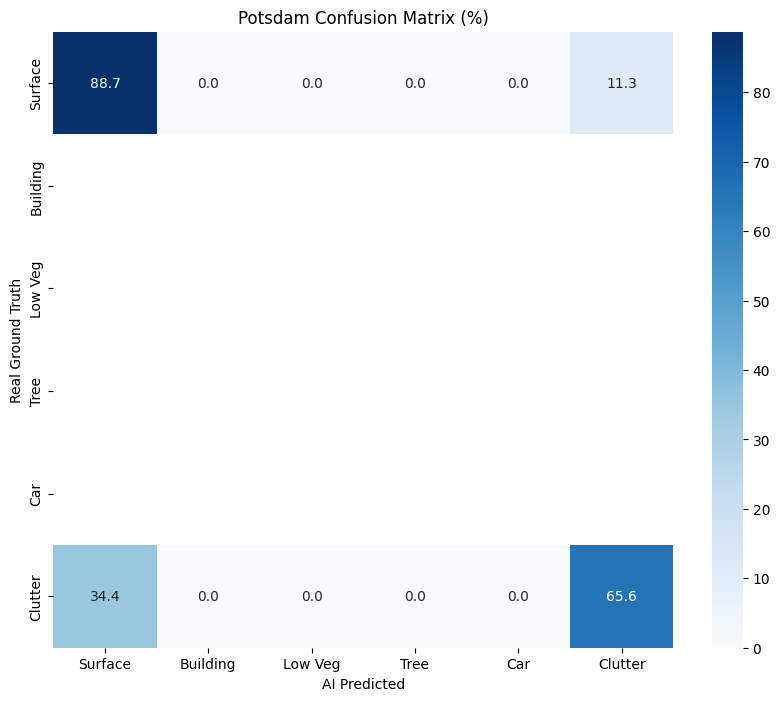

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    class_names = ['Surface', 'Building', 'Low Veg', 'Tree', 'Car', 'Clutter']

    print("🧠 Analyzing class confusion...")
    with torch.no_grad():
        for images, dsms, labels in loader:
            images, dsms = images.to(device), dsms.to(device)
            outputs = model(images, dsms)
            preds = torch.argmax(outputs, dim=1).cpu().numpy().flatten()
            
            targets = labels.numpy().flatten()
            targets[targets > 5] = 5
            
            y_pred.append(preds)
            y_true.append(targets)

    # Prepare data
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    
    # Calculate matrix and normalize by row (to see percentages)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4,5])
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('AI Predicted')
    plt.ylabel('Real Ground Truth')
    plt.title('Potsdam Confusion Matrix (%)')
    plt.show()

# Run it
plot_confusion_matrix(model, train_loader)